# T025 · 激酶相似性：激酶口袋（KiSSim 指纹）

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Dominique Sydow, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Talia B. Kimber, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)


## 本教程的目标

我们将使用 [KiSSim](https://kissim.readthedocs.io/en/latest/) 指纹从结构角度评估一组激酶之间的相似性。该指纹描述了结构已解析的激酶中的物理化学和空间性质。

_注意_：我们关注正构激酶结合位点之间的相似性；变构结合位点的相似性不在讨论范围内。


### _理论_ 部分内容

* 激酶数据集
* 激酶相似性描述符：激酶口袋（KiSSim 指纹）
* 使用 `opencadd.databases.klifs` 获取 KLIFS 数据


### _实践_ 部分内容

* 定义目标激酶
* 检索和预处理数据
    * 建立远程 KLIFS 会话
    * 获取描述这些激酶的所有结构
    * 过滤结构
* 展示激酶覆盖情况
* 计算 KiSSim 指纹
* 比较结构
* 将结构映射到激酶距离矩阵
* 保存激酶距离矩阵


### 参考文献

* 激酶数据集：[<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629)
* 蛋白质数据银行（PDB）
  * PDB URL：http://www.rcsb.org/
  * PDB 数据库：[<i>Acta Cryst.</i> (2002), <b>D58</b>, 899-907](https://doi.org/10.1107/S0907444902003451) 和 [<i>Structure</i> (2012), <b>20(3)</b>, 391-396](https://doi.org/10.1016/j.str.2012.01.010)
* KLIFS
  * KLIFS URL：https://klifs.net/
  * KLIFS 数据库：[<i>Nucleic Acid Res.</i> (2020), <b>49(D1)</b>, D562-D569](https://doi.org/10.1093/nar/gkaa895)
  * KLIFS 结合位点定义：[<i>J. Med. Chem.</i> (2014), <b>57(2)</b>, 249-277](https://doi.org/10.1021/jm400378w)
 * 结合位点比较综述：
   * [<i>Curr. Comput. Aided Drug Des. </i> (2008), <b>4</b>, 209-20](https://www.eurekaselect.com/67606/article/how-measure-similarity-between-protein-ligand-binding-sites)
    * [<i>J. Med. Chem. </i> (2016), <b>9</b>, 4121-51](https://pubs.acs.org/doi/10.1021/acs.jmedchem.6b00078)
* KiSSim：激酶结构相似性
  * GitHub 仓库：https://github.com/volkamerlab/kissim
  * 文档：https://kissim.readthedocs.io
* `opencadd`，用于结构化学信息学的 Python 库
  * GitHub 仓库：https://github.com/volkamerlab/opencadd
  * 文档：https://opencadd.readthedocs.io


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 25
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论


### 激酶数据集


我们使用 **教程 T023** 中定义的激酶选择。


### 激酶相似性描述符：激酶口袋（KiSSim 指纹）

副作用通常发生在药物不仅与预期靶标（on-target）结合，而且还与其他具有相似结合位点的靶标（off-target）结合时，从而形成相似的蛋白质-配体相互作用模式。已经提出了许多结合位点比较工具来预测相似性和潜在的脱靶效应（参见 [<i>Curr. Comput. Aided Drug Des. </i> (2008), <b>4</b>, 209-20](https://www.eurekaselect.com/67606/article/how-measure-similarity-between-protein-ligand-binding-sites) 和 [<i>J. Med. Chem. </i> (2016), <b>9</b>, 4121-51](https://pubs.acs.org/doi/10.1021/acs.jmedchem.6b00078)）。

这里我们使用新颖的 [KiSSim](https://kissim.readthedocs.io/en/latest/)（*Ki*nase *S*tructure *Sim*ilarity，激酶结构相似性）指纹，该指纹基于 KLIFS 口袋定义和对 85 个口袋残基的比对（更多详情见 **教程 T023**）。


KiSSim 指纹根据物理化学和空间属性对 KLIFS 结合位点中的每个 85 个残基进行编码（图 1）。由于所有 KLIFS 口袋在整个结构覆盖的激酶组中都是对齐的，我们可以逐位比较 KiSSim 指纹。每个残基的物理化学属性包括药效团特征、大小、侧链取向和溶剂暴露度。空间属性描述每个残基到激酶口袋中定义的重要区域的距离，例如与配体形成关键氢键的铰链区，或构象决定激酶活性状态的 DFG 区。有关激酶结构基序的更多详细信息，请参阅 **教程 T023**。

![KiSSim 指纹](https://raw.githubusercontent.com/volkamerlab/kissim/main/docs/_static/kissim_toc.png)

*图 1：*
KiSSim 指纹编码激酶结合位点的物理化学和空间属性。
图片来自：https://github.com/volkamerlab/kissim


### 使用 `opencadd.databases.klifs` 获取 KLIFS 数据

`opencadd` 是一个用于结构化学信息学的 Python 库，由柏林 Charité 医学院的 [Volkamer 实验室](https://volkamerlab.org/) 开发。该库是一个不断增长的模块集合，有助于促进和标准化结构生物信息学和化学信息学中的常见任务。今天，我们将使用 `opencadd.databases.klifs` 模块，该模块允许我们以 `pandas` DataFrame 的形式获取 KLIFS 结构。

- GitHub 仓库：https://github.com/volkamerlab/opencadd
- 文档：https://opencadd.readthedocs.io

有关该库和 KLIFS OpenAPI 的更多信息，请参阅 **教程 T012**。


## 实践


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import pairwise
import matplotlib.pyplot as plt
import seaborn as sns
from opencadd.databases.klifs import setup_remote
import kissim

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

In [4]:
configs = pd.read_csv(DATA / "T023_data" / "pipeline_configs.csv")
configs = configs.set_index("variable")["default_value"]

DEMO = bool(int(configs["DEMO"]))
N_STRUCTURES_PER_KINASE = int(configs["N_STRUCTURES_PER_KINASE"])
N_CORES = int(configs["N_CORES"])

print(f"Run in demo mode: {DEMO}")
if not DEMO:
    if N_STRUCTURES_PER_KINASE > 0:
        print(f"Number of structures per kinase: {N_STRUCTURES_PER_KINASE}")
    else:
        print(f"Number of structures per kinase: all available structures")
    print(f"Number of cores used: {N_CORES}")

# NBVAL_CHECK_OUTPUT

Run in demo mode: True


### 定义目标激酶


加载 **教程 T023** 中定义的激酶选择。


In [5]:
kinase_selection_df = pd.read_csv(DATA / "T023_data" / "kinase_selection.csv")
kinase_selection_df
# NBVAL_CHECK_OUTPUT

,kinase,kinase_klifs,uniprot_id,group,full_kinase_name
0,EGFR,EGFR,P00533,TK,Epidermal growth factor receptor
1,ErbB2,ErbB2,P04626,TK,Erythroblastic leukemia viral oncogene homolog 2
2,PI3K,p110a,P42336,Atypical,Phosphatidylinositol-3-kinase
3,VEGFR2,KDR,P35968,TK,Vascular endothelial growth factor receptor 2
4,BRAF,BRAF,P15056,TKL,Rapidly accelerated fibrosarcoma isoform B
5,CDK2,CDK2,P24941,CMGC,Cyclic-dependent kinase 2
6,LCK,LCK,P06239,TK,Lymphocyte-specific protein tyrosine kinase
7,MET,MET,P08581,TK,Mesenchymal-epithelial transition factor
8,p38a,p38a,Q16539,CMGC,p38 mitogen activated protein kinase alpha


### 检索和预处理数据


现在，我们使用 `opencadd.databases.klifs` 模块查询 KLIFS 数据库，以获取 KLIFS 中可用的结构。


#### 建立远程 KLIFS 会话


In [6]:
from opencadd.databases.klifs import setup_remote

In [7]:
klifs_session = setup_remote()

#### 获取描述这些激酶的所有结构


In [8]:
# 获取激酶名称列表
kinase_names = kinase_selection_df["kinase_klifs"].to_list()

# 获取这些激酶的所有可用结构
structures_df = klifs_session.structures.by_kinase_name(kinase_names=kinase_names)
print(f"Number of structures: {len(structures_df)}")
print("Kinases:", *structures_df["kinase.klifs_name"].unique())

Number of structures: 2763
Kinases: CDK2 p38a EGFR ErbB2 MET LCK KDR BRAF p110a


让我们看看结构 DataFrame 中存储了什么：


In [9]:
structures_df.columns

Index(['structure.klifs_id', 'structure.pdb_id', 'structure.alternate_model',
       'structure.chain', 'species.klifs', 'kinase.klifs_id',
       'kinase.klifs_name', 'kinase.names', 'kinase.family', 'kinase.group',
       'structure.pocket', 'ligand.expo_id', 'ligand_allosteric.expo_id',
       'ligand.klifs_id', 'ligand_allosteric.klifs_id', 'ligand.name',
       'ligand_allosteric.name', 'structure.dfg', 'structure.ac_helix',
       'structure.resolution', 'structure.qualityscore',
       'structure.missing_residues', 'structure.missing_atoms',
       'structure.rmsd1', 'structure.rmsd2', 'interaction.fingerprint',
       'structure.front', 'structure.gate', 'structure.back', 'structure.fp_i',
       'structure.fp_ii', 'structure.bp_i_a', 'structure.bp_i_b',
       'structure.bp_ii_in', 'structure.bp_ii_a_in', 'structure.bp_ii_b_in',
       'structure.bp_ii_out', 'structure.bp_ii_b', 'structure.bp_iii',
       'structure.bp_iv', 'structure.bp_v', 'structure.grich_distance',
       

In [10]:
structures_df.head()

,structure.klifs_id,structure.pdb_id,structure.alternate_model,structure.chain,species.klifs,kinase.klifs_id,kinase.klifs_name,kinase.names,kinase.family,kinase.group,...,structure.bp_ii_out,structure.bp_ii_b,structure.bp_iii,structure.bp_iv,structure.bp_v,structure.grich_distance,structure.grich_angle,structure.grich_rotation,structure.filepath,structure.curation_flag
0,4071,2uze,-,C,Human,198,CDK2,<NA>,<NA>,<NA>,...,False,False,False,False,False,14.8615,50.178501,78.147003,<NA>,False
1,4151,3bht,A,C,Human,198,CDK2,<NA>,<NA>,<NA>,...,False,False,False,False,False,15.7468,52.163101,61.316200,<NA>,False
2,4152,2r3h,A,A,Human,198,CDK2,<NA>,<NA>,<NA>,...,False,False,False,False,False,14.2932,50.137600,69.559502,<NA>,False
3,4153,4eon,A,C,Human,198,CDK2,<NA>,<NA>,<NA>,...,False,False,False,False,False,14.5531,48.250301,75.158096,<NA>,False
4,4154,2j9m,A,A,Human,198,CDK2,<NA>,<NA>,<NA>,...,False,False,False,False,False,13.5160,45.962101,61.240601,<NA>,False


#### 过滤结构

我们按不同标准过滤结构：

- 物种：人（human）
- 构象：DFG-in（活性激酶构象）
- 分辨率：≤ 3 Å
- 质量评分*：≥ 6

* KLIFS 质量评分考虑了比对的质量以及缺失残基和原子的数量。分数越高表示结构质量越好。


In [11]:
structures_df = structures_df[
    (structures_df["species.klifs"] == "Human")
    & (structures_df["structure.dfg"] == "in")
    & (structures_df["structure.resolution"] <= 3)
    & (structures_df["structure.qualityscore"] >= 6)
]
print(f"Number of structures: {len(structures_df)}")
print("Kinases:", *structures_df["kinase.klifs_name"].unique())

Number of structures: 1820
Kinases: CDK2 p38a EGFR ErbB2 MET LCK KDR BRAF p110a


保存结构 KLIFS ID 以供下一步使用。


In [12]:
structure_klifs_ids = structures_df["structure.klifs_id"].to_list()
print(f"Number of structures: {len(structure_klifs_ids)}")

Number of structures: 1820


_演示模式说明_：为了方便我们维护教程，我们现在加载一组冻结的结构 KLIFS ID（2021-08-23），并继续使用这些数据。

_非演示模式说明_：你是否在配置文件中指定了 `N_STRUCTURES_PER_KINASE`？如果你设置了例如 3，我们将在下面根据分辨率和 KLIFS 质量评分选择每个激酶的前 3 个结构。


In [13]:
if DEMO:
    # 加载冻结的数据集
    print("Notebook 以演示模式运行 - 加载冻结的结构集。")
    structure_klifs_ids = pd.read_csv(DATA / "frozen_structure_klifs_ids.csv")[
        "structure.klifs_id"
    ].to_list()
    structures_df = structures_df[
        structures_df["structure.klifs_id"].isin(structure_klifs_ids)
    ].copy()
else:
    if N_STRUCTURES_PER_KINASE > 0:
        print(f"Select {N_STRUCTURES_PER_KINASE} structures per kinase for downstream analysis.")
        # Sort structures by kinase and quality
        structures_df = structures_df.sort_values(
            by=["kinase.klifs_name", "structure.resolution", "structure.qualityscore"],
            ascending=[True, True, False],
        )
        # Reduce number of structures per kinase
        structures_df = structures_df.groupby("kinase.klifs_name").head(N_STRUCTURES_PER_KINASE)
        structure_klifs_ids = structures_df["structure.klifs_id"].to_list()
    else:
        print(f"Use all available structures per kinase for downstream analysis.")

print(f"Number of structures: {structures_df.shape[0]}")
# NBVAL_CHECK_OUTPUT

Notebook is run in demo mode - load frozen structure set.
Number of structures: 1620


### 展示激酶覆盖情况

让我们获取描述我们激酶的结构数量（激酶覆盖情况）。


In [14]:
# 使用 pandas 的 groupby 方法统计每个激酶的结构（行）数量
n_structures_per_kinase = structures_df.groupby("kinase.klifs_name").size().sort_values()
n_structures_per_kinase
# NBVAL_CHECK_OUTPUT

kinase.klifs_name
ErbB2      4
KDR        6
LCK       32
p110a     49
BRAF      72
MET       99
p38a     151
EGFR     357
CDK2     850
dtype: int64

绘制结果。


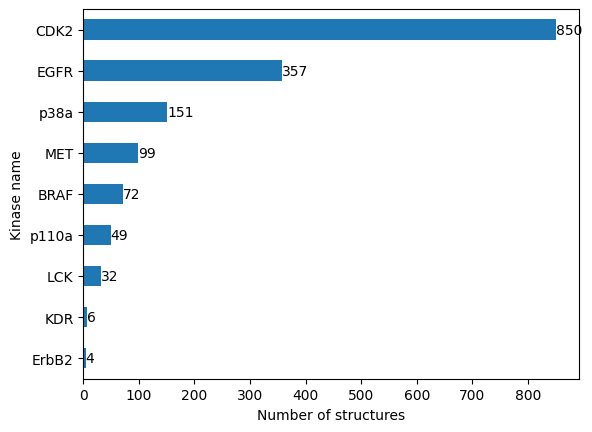

In [15]:
fig, ax = plt.subplots()
n_structures_per_kinase.plot(kind="barh", ax=ax)
ax.set_xlabel("Number of structures")
ax.set_ylabel("Kinase name")
for i, value in enumerate(n_structures_per_kinase):
    ax.text(value, i, str(value), va="center")

我们看到我们的数据集严重不平衡。虽然某些激酶被频繁解析出结构，但其他激酶则不然。在后续解释结果时，我们需要记住这一点。


### 计算 KiSSim 指纹


我们使用 `kissim` API 将我们的结构编码为 KiSSim 指纹，并将指纹保存为 CSV 文件。

_演示模式说明_：我们使用预先计算的 KiSSim 指纹作为我们的激酶集（即下一个代码单元格将被跳过）。


In [16]:
if DEMO:
    print("Notebook 以演示模式运行 - 我们将使用预先计算的指纹。")
else:
    print("计算并保存 KiSSim 指纹...")
    # 计算指纹
    from kissim.api import encode

    kissim_fingerprints = encode(structure_klifs_ids, n_cores=N_CORES)

    # 将指纹保存为 CSV 文件
    structure_klifs_ids = list(kissim_fingerprints.data.keys())
    kissim_fingerprints_array = [
        fingerprint.values_array().tolist()
        for structure_klifs_id, fingerprint in kissim_fingerprints.data.items()
    ]
    kissim_fingerprints_array = np.array(kissim_fingerprints_array)
    kissim_fingerprints_df = pd.DataFrame(kissim_fingerprints_array, index=structure_klifs_ids)
    kissim_fingerprints_df.to_csv(DATA / "kissim_fingerprints.csv")

# NBVAL_CHECK_OUTPUT

Notebook is run in demo mode - we will use pre-calculated fingerprints.


让我们从 CSV 文件加载 KiSSim 指纹。


In [17]:
kissim_fingerprints_df = pd.read_csv(DATA / "kissim_fingerprints.csv", index_col=0)
print(f"Matrix shape: {kissim_fingerprints_df.shape}")
print(f"Number of fingerprints: {kissim_fingerprints_df.shape[0]}")
print(f"Number of fingerprint bits: {kissim_fingerprints_df.shape[1]}")
# NBVAL_CHECK_OUTPUT

Matrix shape: (1611, 1032)
Number of fingerprints: 1611
Number of fingerprint bits: 1032


你可能会注意到我们的指纹数量略少于结构数量。这种情况可能发生在 `kissim` 指纹生成过程中，如果某个结构无法被编码的话。


让我们看看指纹 DataFrame。

- 激酶结构以 KLIFS ID 存储（索引）
- 每个激酶由 1032 个特征表示，即 85 个残基 × 8 个物理化学特征 + 85 个残基 × 4 个距离 + 12 个矩量


In [18]:
kissim_fingerprints_df.head()
# NBVAL_CHECK_OUTPUT

,0,1,2,3,4,5,6,7,8,9,...,1022,1023,1024,1025,1026,1027,1028,1029,1030,1031
6285,2.0,0.0,2.0,-1.0,0.0,0.0,2.0,3.0,2.0,1.0,...,13.150351,11.958837,4.717011,4.843444,4.655707,3.577213,2.771821,4.302192,3.583341,2.066700
10568,2.0,0.0,2.0,-1.0,0.0,0.0,2.0,3.0,2.0,1.0,...,13.069152,11.883944,4.691527,5.006221,4.679352,3.531177,2.714736,4.165350,3.549843,2.138838
11187,2.0,0.0,2.0,-1.0,0.0,0.0,2.0,3.0,2.0,1.0,...,13.297023,11.991511,4.590040,5.141397,4.699467,3.625989,2.549692,4.442117,3.699695,2.261646
4060,2.0,0.0,2.0,-1.0,0.0,0.0,2.0,3.0,2.0,1.0,...,12.910837,11.775556,4.359330,4.844833,4.214195,3.383812,2.699580,3.860920,3.161863,2.185979
10566,2.0,0.0,2.0,-1.0,0.0,0.0,2.0,3.0,2.0,1.0,...,13.196581,12.115342,4.701176,4.690081,4.683674,3.633418,2.489983,3.972552,3.692501,0.759234


### 比较结构

让我们进行 KiSSim 指纹的成对比较。我们使用 `sklearn` 的 `nan_euclidean_distances` 方法，该方法计算所有成对向量之间的欧氏距离。

如果两个向量具有 NaN 值（当结构中某些残基未被解析时可能发生），将应用以下步骤：

> 在计算一对样本之间的距离时，此公式会忽略任一样本中缺失值的特征坐标，并缩放剩余坐标的权重。

更多信息请参见 [sklearn 文档](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.nan_euclidean_distances.html)。


In [19]:
structure_distance_matrix_array = pairwise.nan_euclidean_distances(kissim_fingerprints_df.values)

In [20]:
# 创建以结构 KLIFS ID 为索引/列名的 DataFrame
structure_klifs_ids = kissim_fingerprints_df.index.to_list()
structure_distance_matrix_df = pd.DataFrame(
    structure_distance_matrix_array, index=structure_klifs_ids, columns=structure_klifs_ids
)
print(f"Structure distance matrix size: {structure_distance_matrix_df.shape}")
print("Show matrix subset:")
structure_distance_matrix_df.iloc[:5, :5]
# NBVAL_CHECK_OUTPUT

Structure distance matrix size: (1611, 1611)
Show matrix subset:


,6285,10568,11187,4060,10566
6285,0.000000,13.256941,14.001474,26.391543,14.307291
10568,13.256941,0.000000,10.379779,27.882193,16.833932
11187,14.001474,10.379779,0.000000,30.962221,18.338492
4060,26.391543,27.882193,30.962221,0.000000,28.905189
10566,14.307291,16.833932,18.338492,28.905189,0.000000


### 将结构映射到激酶距离矩阵

注意：到目前为止我们比较的是单个结构，但我们想要比较的是激酶（如上所述，每个激酶可能由多个结构表示）。

首先，作为一个中间步骤，我们将使用结构距离矩阵，但不是用结构 KLIFS ID 标记数据，而是使用对应的激酶名称。


In [21]:
# 复制距离矩阵到激酶矩阵
kinase_distance_matrix_df = structure_distance_matrix_df.copy()
# 将结构 KLIFS ID 替换为结构的激酶名称
kinase_names = structures_df.set_index("structure.klifs_id").loc[
    structure_klifs_ids, "kinase.klifs_name"
]
kinase_distance_matrix_df.index = kinase_names
kinase_distance_matrix_df.columns = kinase_names
print("Show matrix subset:")
kinase_distance_matrix_df.iloc[:5, :5]
# NBVAL_CHECK_OUTPUT

Show matrix subset:


kinase.klifs_name,CDK2,CDK2,CDK2,CDK2,CDK2
kinase.klifs_name,,,,,
CDK2,0.000000,13.256941,14.001474,26.391543,14.307291
CDK2,13.256941,0.000000,10.379779,27.882193,16.833932
CDK2,14.001474,10.379779,0.000000,30.962221,18.338492
CDK2,26.391543,27.882193,30.962221,0.000000,28.905189
CDK2,14.307291,16.833932,18.338492,28.905189,0.000000


在本教程中，对于每对激酶，我们将考虑显示最相似口袋的两个结构。因此，我们选择距离最小的结构对作为该激酶对的代表。


In [23]:
# 展开矩阵（每个成对比较放在单独的行中）
# 按激酶名称分组（level=[0, 1] 确保忽略激酶的先后顺序）
# 取每个激酶对组中的最小值
# 展开剩余数据点

# 在展开前移除重复的列和行
# 确保 DataFrame 的索引和列都是唯一的，
# which is required for the reshaping operation.

# Deduplicate columns (keeping first occurrence)
kinase_distance_matrix_df = kinase_distance_matrix_df.loc[
    :, ~kinase_distance_matrix_df.columns.duplicated()
]

# Deduplicate index (keeping first occurrence)
kinase_distance_matrix_df = kinase_distance_matrix_df.loc[
    ~kinase_distance_matrix_df.index.duplicated(), :
]


kinase_distance_matrix_df = (
    kinase_distance_matrix_df.unstack().groupby(level=[0, 1]).min().unstack(level=1)
)
# Cosmetics: Remove the index and column names
kinase_distance_matrix_df.index.name = None
kinase_distance_matrix_df.columns.name = None

In [24]:
print(
    f"Structure matrix of shape {structure_distance_matrix_df.shape} "
    f"reduced to kinase matrix of shape {kinase_distance_matrix_df.shape}."
)
# NBVAL_CHECK_OUTPUT

Structure matrix of shape (1611, 1611) reduced to kinase matrix of shape (9, 9).


In [25]:
# Show matrix with background gradient
cm = sns.light_palette("green", as_cmap=True)
kinase_distance_matrix_df.style.background_gradient(cmap=cm).format("{:.3f}")

,BRAF,CDK2,EGFR,ErbB2,KDR,LCK,MET,p110a,p38a
BRAF,0.000,20.030,21.296,30.338,36.280,36.685,29.407,47.624,33.819
CDK2,20.030,0.000,20.142,27.643,33.120,33.564,22.808,49.992,30.867
EGFR,21.296,20.142,0.000,25.511,32.217,34.004,25.062,49.792,30.862
ErbB2,30.338,27.643,25.511,0.000,27.387,32.255,31.749,45.460,33.771
KDR,36.280,33.120,32.217,27.387,0.000,22.216,34.591,42.744,22.021
LCK,36.685,33.564,34.004,32.255,22.216,0.000,34.556,40.387,32.231
MET,29.407,22.808,25.062,31.749,34.591,34.556,0.000,51.528,31.812
p110a,47.624,49.992,49.792,45.460,42.744,40.387,51.528,0.000,44.875
p38a,33.819,30.867,30.862,33.771,22.021,32.231,31.812,44.875,0.000


注意：由于这是距离矩阵，较浅的颜色表示相似性，较深的颜色表示不相似性。


### 保存激酶距离矩阵


In [26]:
kinase_distance_matrix_df.to_csv(DATA / "kinase_distance_matrix.csv")

## 讨论

在本教程中，我们使用 KiSSim 指纹评估了激酶相似性，该指纹描述了激酶结构中口袋的物理化学和空间属性。我们通过为每个_激酶对_选择对应的最近_结构对_，将_结构_距离矩阵简化为_激酶_距离矩阵。

我们需要牢记两个问题：

- KiSSim 等口袋指纹对整个口袋进行编码，尽管某些残基可能比其他残基对配体结合更重要。作为替代方案，可以使用已被证明频繁与共晶配体相互作用的一个残基子集。
- 我们在此仅比较每对激酶最近的两个结构，尽管我们（至少对于 EGFR 和 CDK2 等激酶）有更多的结构数据可用。聚合多个结构是一种合理的策略，但有两个缺点：
  - 某些激酶的覆盖度远高于其他激酶，导致信息含量不平衡。
  - 聚合的激酶指纹可能导致过多的平均化，使得激酶成对比较的噪声更大。

上述激酶距离矩阵将在 **教程 T028** 中重新加载，届时我们将从不同角度比较激酶相似性，包括本教程中讨论的口袋结构角度。


## 测验

1. 你能想到为什么在指纹中包含物理化学和空间属性很重要吗？
2. 你能想到为什么侧链取向和溶剂暴露度是指纹中值得考虑的有趣特征吗？
3. 你能想到在哪些研究问题中可以使用结构距离矩阵吗？
